# Molecular Subtype Classification of TCGA-BRCA Whole-Slide Images

## Problem Definition

We address the task of **PAM50 molecular subtype classification** from H&E-stained whole-slide images (WSI) in the TCGA-BRCA cohort.

The classification target consists of **4 molecular subtypes**:

| Class | Label | Description |
|-------|-------|-------------|
| 0 | **Luminal A** | Hormone receptor-positive, low proliferation |
| 1 | **Luminal B** | Hormone receptor-positive, higher proliferation |
| 2 | **Basal-like** | Triple-negative, aggressive |
| 3 | **HER2-enriched** | HER2 overexpression |

Slides labelled as *Normal-like* are excluded from training and evaluation, consistent with standard practice.

**Dataset statistics** (after exclusion): 986 diagnostic slides from TCGA-BRCA, distributed as:

- Luminal A: 508 slides (51.5\%)
- Luminal B: 222 slides (22.5\%)
- Basal-like: 173 slides (17.5\%)
- HER2-enriched: 83 slides (8.4\%)

## Pipeline

The classification pipeline follows a two-stage **Multiple Instance Learning (MIL)** approach:

### Stage 1: Patch Feature Extraction -- UNI2-h

Each WSI is tessellated into non-overlapping 224x224 patches at 20x magnification. Patch-level features are extracted using **UNI2-h** (Mahmood Lab), a ViT-Giant/14 foundation model pre-trained on over 100M histopathology images. Each patch is represented as a **1536-dimensional** embedding vector. The resulting bag of embeddings per slide is stored as an HDF5 file.

### Stage 2: Slide-Level Classification -- CLAM-MB

Slide-level predictions are made using **CLAM-MB** (Clustering-constrained Attention Multiple Instance Learning, Multi-Branch variant). CLAM-MB uses gated attention to learn which patches are most informative for each class and aggregates them into a slide-level representation. The model is trained with:

- **Bag-level loss**: Cross-entropy with label smoothing (0.1)
- **Instance-level loss**: SmoothTop1SVM (auxiliary clustering constraint)
- **Weighted random sampling** to address class imbalance
- **Early stopping** on validation AUC (patience = 5 epochs)

## Experimental Setup

### Hyperparameter Optimization

Hyperparameters were tuned via **Bayesian optimization** (W&B Sweeps), maximizing **validation AUC** on fold 0. The search space included:

| Parameter | Search Space |
|-----------|-------------|
| Learning rate | Log-uniform \[1e-4, 1e-3\] |
| Weight decay | Log-uniform \[5e-4, 1e-2\] |
| Dropout | \{0.25, 0.5, 0.6, 0.75\} |
| Model variant | \{CLAM-SB, CLAM-MB\} |
| Attention size | \{small, big\} |
| Bag weight | Uniform \[0.7, 0.95\] |
| Top-k patches (B) | \{4, 8, 16\} |
| Instance loss | SVM (fixed) |
| Early stopping patience | \{3, 5, 7\} |

### Best Configuration (selected by validation AUC)

| Parameter | Value |
|-----------|-------|
| Model | CLAM-MB, big |
| Learning rate | 1.008e-4 |
| Weight decay | 2.446e-6 |
| Dropout | 0.5 |
| Bag weight | 0.553 |
| Top-k patches (B) | 4 |
| Instance loss | SVM |
| Optimizer | Adam |
| Max epochs | 50 |
| Early stopping patience | 5 |

### Evaluation Protocol

The best configuration was evaluated using **stratified 10-fold cross-validation** with patient-level stratification. Each slide appears in exactly one test fold, so aggregating predictions across all folds yields held-out predictions for the entire dataset without data leakage.

## Results

In [1]:
import os
import pickle
import warnings

warnings.filterwarnings("ignore")
os.environ["JOBLIB_START_METHOD"] = "forkserver"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc as calc_auc,
)
from sklearn.preprocessing import label_binarize

PALETTE = ["#2563EB", "#DC2626", "#16A34A", "#D97706"]
CLASS_COLORS = dict(zip(["LumA", "LumB", "Basal", "Her2"], PALETTE))

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})

In [2]:
RESULTS_DIR = "../.scratch/results/pam50_final_s1"
N_FOLDS = 10
N_CLASSES = 4
CLASS_NAMES = ["LumA", "LumB", "Basal", "Her2"]

### Per-Fold Validation and Test Metrics

Table 1 shows per-fold AUC (macro one-vs-rest) and overall accuracy for both validation and test sets.

In [3]:
summary_path = os.path.join(RESULTS_DIR, "summary.csv")
df_summary = pd.read_csv(summary_path, index_col=0)
df_summary["folds"] = df_summary["folds"].astype(int)
df_summary = df_summary.set_index("folds")
df_summary.index.name = "Fold"

mean_row = df_summary.mean()
std_row = df_summary.std()

print("Table 1: Per-Fold Results")
print("=" * 55)
print(df_summary.to_string(float_format=lambda x: f"{x:.4f}"))
print("-" * 55)
for col in df_summary.columns:
    print(f"  {col:10s}  Mean +/- Std: {mean_row[col]:.4f} +/- {std_row[col]:.4f}")
print("=" * 55)

Table 1: Per-Fold Results
      test_auc  val_auc  test_acc  val_acc
Fold                                      
0       0.9197   0.9250    0.6699   0.7885
1       0.8669   0.8577    0.7234   0.6354
2       0.8487   0.9044    0.6598   0.7670
3       0.9217   0.9132    0.7879   0.7500
4       0.8916   0.9082    0.7576   0.7677
5       0.8942   0.8999    0.7292   0.7053
6       0.9015   0.9214    0.6796   0.7576
7       0.9099   0.8944    0.7263   0.7475
8       0.9150   0.8925    0.7677   0.7789
9       0.8602   0.9030    0.6832   0.7449
-------------------------------------------------------
  test_auc    Mean +/- Std: 0.8930 +/- 0.0260
  val_auc     Mean +/- Std: 0.9019 +/- 0.0188
  test_acc    Mean +/- Std: 0.7184 +/- 0.0441
  val_acc     Mean +/- Std: 0.7443 +/- 0.0445


### Aggregated Predictions

Since each slide appears in exactly one test fold, we aggregate all per-slide test predictions across the 10 folds to obtain held-out predictions for the full dataset.

In [4]:
all_labels = []
all_probs = []
all_slide_ids = []

for fold in range(N_FOLDS):
    pkl_path = os.path.join(RESULTS_DIR, f"split_{fold}_results.pkl")
    with open(pkl_path, "rb") as f:
        results = pickle.load(f)
    for slide_id, entry in results.items():
        all_slide_ids.append(slide_id)
        all_labels.append(int(entry["label"]))
        all_probs.append(entry["prob"].flatten()[:N_CLASSES])

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = np.argmax(all_probs, axis=1)

print(f"Total slides evaluated: {len(all_labels)}")
dist = dict(zip(CLASS_NAMES, np.bincount(all_labels, minlength=N_CLASSES)))
print(f"Class distribution: {dist}")

Total slides evaluated: 986
Class distribution: {'LumA': 508, 'LumB': 222, 'Basal': 173, 'Her2': 83}


### Per-Fold Test AUC

Figure 1 compares validation and test AUC across the 10 folds. The dashed red line and shaded band show the mean +/- 1 std of the test AUC.

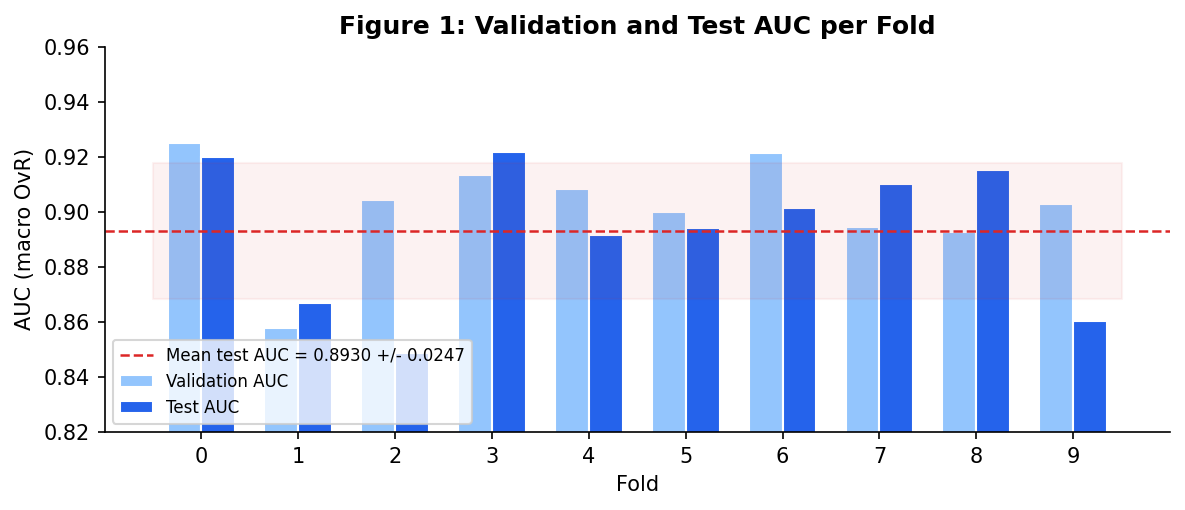

In [5]:
test_aucs = df_summary["test_auc"].values
val_aucs = df_summary["val_auc"].values
folds = np.arange(N_FOLDS)

fig, ax = plt.subplots(figsize=(8, 3.5))

width = 0.35
ax.bar(folds - width/2, val_aucs, width, label="Validation AUC", color="#93C5FD", edgecolor="white")
ax.bar(folds + width/2, test_aucs, width, label="Test AUC", color="#2563EB", edgecolor="white")

mean_test = test_aucs.mean()
std_test = test_aucs.std()
ax.axhline(mean_test, color="#DC2626", ls="--", lw=1.2,
           label=f"Mean test AUC = {mean_test:.4f} +/- {std_test:.4f}")
ax.fill_between([-0.5, N_FOLDS - 0.5], mean_test - std_test, mean_test + std_test,
                color="#DC2626", alpha=0.06)

ax.set_xlabel("Fold")
ax.set_ylabel("AUC (macro OvR)")
ax.set_title("Figure 1: Validation and Test AUC per Fold")
ax.set_xticks(folds)
ax.set_ylim([0.82, 0.96])
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

### Confusion Matrix (Aggregated Test Predictions)

Figure 2 shows the confusion matrix for all 986 held-out predictions, both as raw counts (left) and row-normalised recall (right).

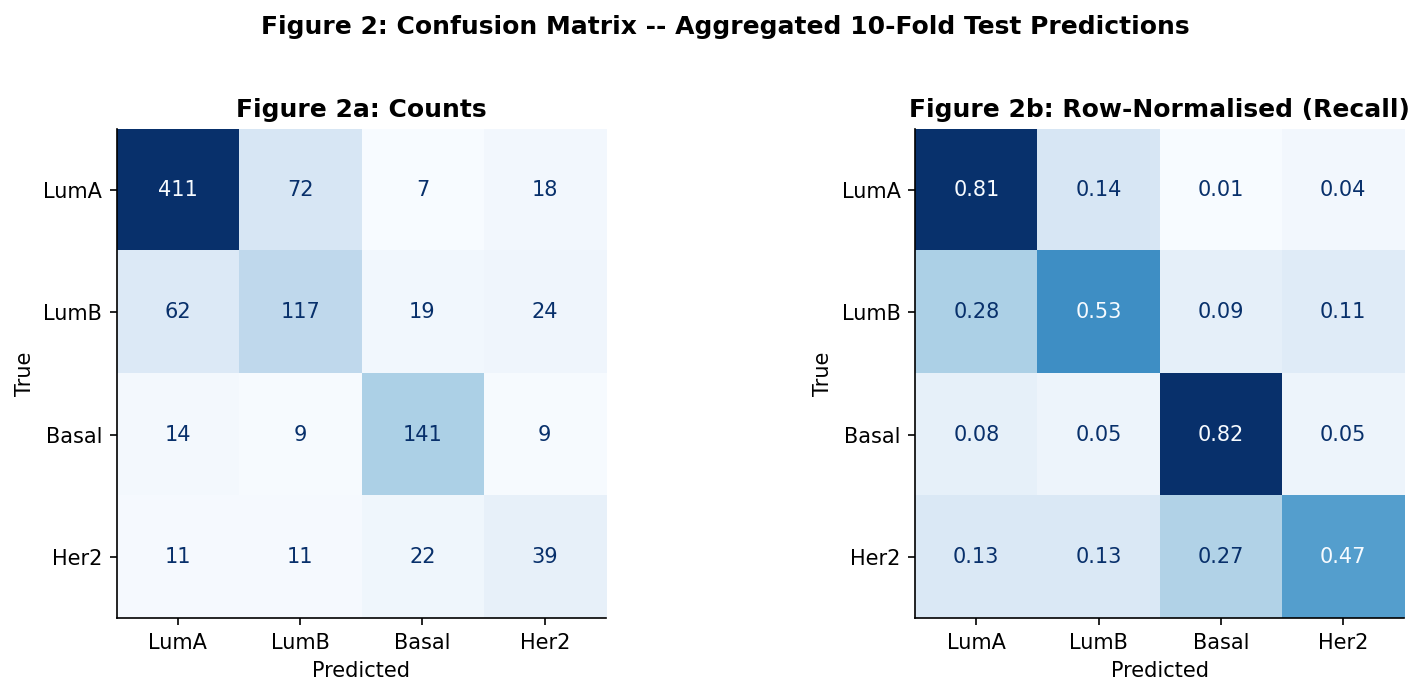

In [6]:
cm_raw = confusion_matrix(all_labels, all_preds)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay(cm_raw, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Figure 2a: Counts")

ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES).plot(
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title("Figure 2b: Row-Normalised (Recall)")

for a in axes:
    a.set_xlabel("Predicted")
    a.set_ylabel("True")

fig.suptitle("Figure 2: Confusion Matrix -- Aggregated 10-Fold Test Predictions",
             fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### Classification Report (Aggregated Test Predictions)

In [7]:
report = classification_report(
    all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True
)

print("Table 2: Classification Report -- Aggregated 10-Fold Test Predictions")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
print("=" * 60)

Table 2: Classification Report -- Aggregated 10-Fold Test Predictions
              precision    recall  f1-score   support

        LumA       0.83      0.81      0.82       508
        LumB       0.56      0.53      0.54       222
       Basal       0.75      0.82      0.78       173
        Her2       0.43      0.47      0.45        83

    accuracy                           0.72       986
   macro avg       0.64      0.66      0.65       986
weighted avg       0.72      0.72      0.72       986



### ROC Curves (Aggregated Test Predictions)

Figure 3 shows one-vs-rest ROC curves for each molecular subtype computed on the aggregated held-out predictions.

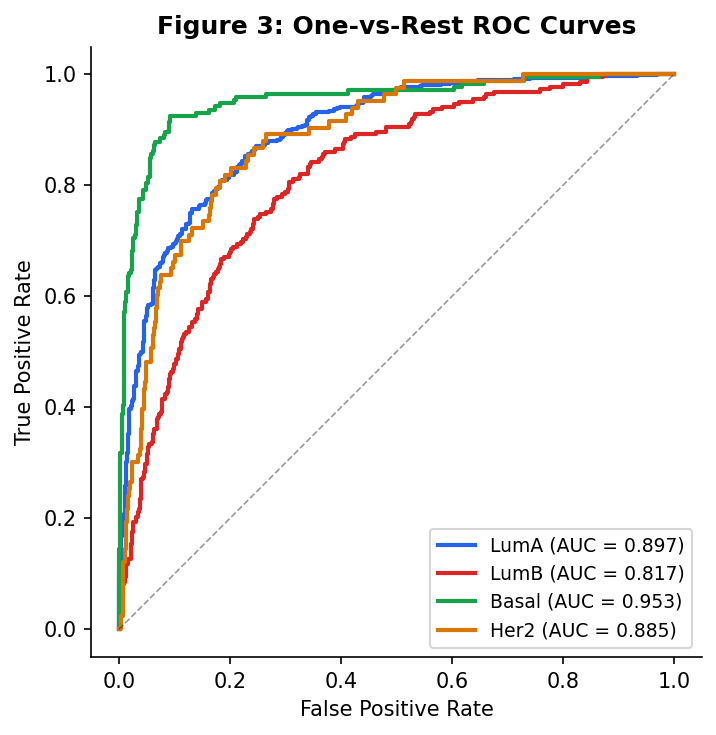

In [8]:
binary_labels = label_binarize(all_labels, classes=list(range(N_CLASSES)))

fig, ax = plt.subplots(figsize=(5.5, 5))

class_aucs = []
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(binary_labels[:, i], all_probs[:, i])
    auc_val = calc_auc(fpr, tpr)
    class_aucs.append(auc_val)
    ax.plot(fpr, tpr, color=CLASS_COLORS[name], lw=2,
            label=f"{name} (AUC = {auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 3: One-vs-Rest ROC Curves")
ax.legend(fontsize=9, loc="lower right")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

### Per-Class AUC Across Folds

Table 3 and Figure 4 break down the test AUC by class for each fold.

In [9]:
rows = []
for fold in range(N_FOLDS):
    pkl_path = os.path.join(RESULTS_DIR, f"split_{fold}_results.pkl")
    with open(pkl_path, "rb") as f:
        results = pickle.load(f)

    labels_f = np.array([int(v["label"]) for v in results.values()])
    probs_f = np.array([v["prob"].flatten()[:N_CLASSES] for v in results.values()])
    binary_f = label_binarize(labels_f, classes=list(range(N_CLASSES)))

    row = {"Fold": fold}
    for i, name in enumerate(CLASS_NAMES):
        if binary_f[:, i].sum() > 0:
            fpr, tpr, _ = roc_curve(binary_f[:, i], probs_f[:, i])
            row[name] = calc_auc(fpr, tpr)
        else:
            row[name] = np.nan
    rows.append(row)

df_class_auc = pd.DataFrame(rows).set_index("Fold")
mean_cls = df_class_auc.mean()
std_cls = df_class_auc.std()

print("Table 3: Per-Class Test AUC by Fold")
print("=" * 50)
print(df_class_auc.to_string(float_format=lambda x: f"{x:.4f}"))
print("-" * 50)
print("Mean +/- Std:")
for name in CLASS_NAMES:
    print(f"  {name:6s}: {mean_cls[name]:.4f} +/- {std_cls[name]:.4f}")
print("=" * 50)

Table 3: Per-Class Test AUC by Fold
       LumA   LumB  Basal   Her2
Fold                            
0    0.8977 0.8805 0.9466 0.9539
1    0.8762 0.7041 0.9607 0.9268
2    0.8905 0.8064 0.9088 0.7893
3    0.9220 0.8666 0.9914 0.9066
4    0.8980 0.8129 0.9739 0.8815
5    0.8903 0.8750 0.9352 0.8764
6    0.9230 0.8405 0.9439 0.8987
7    0.9503 0.8088 0.9755 0.9052
8    0.8971 0.8484 0.9491 0.9657
9    0.8678 0.7946 0.9352 0.8430
--------------------------------------------------
Mean +/- Std:
  LumA  : 0.9013 +/- 0.0243
  LumB  : 0.8238 +/- 0.0521
  Basal : 0.9520 +/- 0.0240
  Her2  : 0.8947 +/- 0.0518


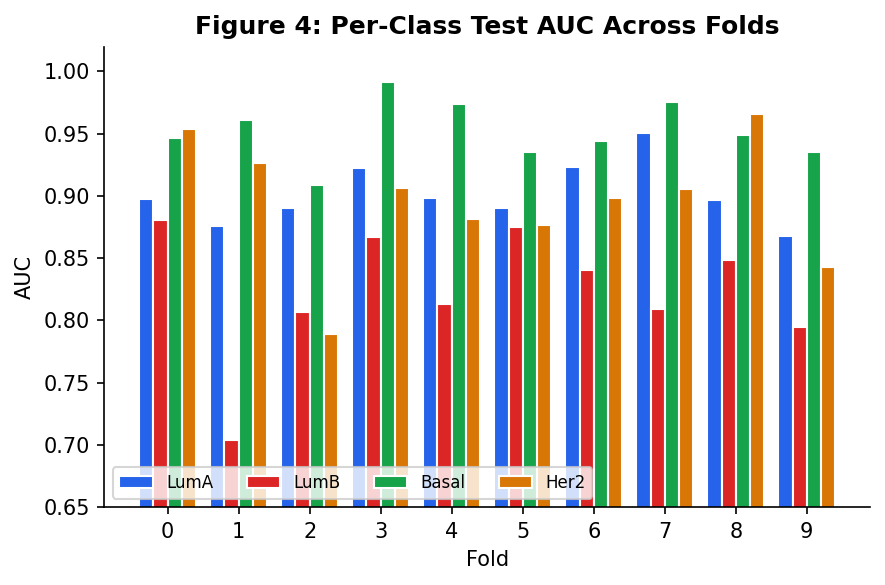

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(N_FOLDS)
width = 0.2
for idx, name in enumerate(CLASS_NAMES):
    vals = df_class_auc[name].values
    ax.bar(x + idx * width, vals, width, label=name, color=CLASS_COLORS[name], edgecolor="white")

ax.set_xlabel("Fold")
ax.set_ylabel("AUC")
ax.set_title("Figure 4: Per-Class Test AUC Across Folds")
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels([str(i) for i in range(N_FOLDS)])
ax.set_ylim([0.65, 1.02])
ax.legend(fontsize=8, ncol=4, loc="lower left")
fig.tight_layout()
plt.show()

## Summary

The table below summarises the final results of the **CLAM-MB + UNI2-h** pipeline on TCGA-BRCA molecular subtype classification using 10-fold cross-validation.

In [11]:
overall_auc = roc_auc_score(
    binary_labels, all_probs, multi_class="ovr", average="macro"
)
overall_acc = (all_preds == all_labels).mean()
report_dict = classification_report(
    all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True
)
weighted_f1 = report_dict["weighted avg"]["f1-score"]

print("=" * 60)
print("  CLAM-MB + UNI2-h | PAM50 Subtyping | 10-Fold CV")
print("=" * 60)
print()
print("--- Validation Set ---")
print(f"  Macro AUC (mean +/- std):  {mean_row['val_auc']:.4f} +/- {std_row['val_auc']:.4f}")
print(f"  Accuracy  (mean +/- std):  {mean_row['val_acc']:.4f} +/- {std_row['val_acc']:.4f}")
print()
print("--- Test Set (aggregated held-out predictions) ---")
print(f"  Macro AUC (aggregated):    {overall_auc:.4f}")
print(f"  Macro AUC (mean +/- std):  {mean_row['test_auc']:.4f} +/- {std_row['test_auc']:.4f}")
print(f"  Overall Accuracy:          {overall_acc:.4f}")
print(f"  Weighted F1-Score:         {weighted_f1:.4f}")
print()
print("--- Per-Class Test Results ---")
print(f"  {'Class':6s}  {'AUC':>6s}  {'Prec':>6s}  {'Recall':>6s}  {'F1':>6s}  {'n':>5s}")
print(f"  {'-'*6}  {'-'*6}  {'-'*6}  {'-'*6}  {'-'*6}  {'-'*5}")
for i, name in enumerate(CLASS_NAMES):
    r = report_dict[name]
    print(f"  {name:6s}  {class_aucs[i]:6.4f}  {r['precision']:6.3f}  {r['recall']:6.3f}  {r['f1-score']:6.3f}  {int(r['support']):5d}")
print("=" * 60)

  CLAM-MB + UNI2-h | PAM50 Subtyping | 10-Fold CV

--- Validation Set ---
  Macro AUC (mean +/- std):  0.9019 +/- 0.0188
  Accuracy  (mean +/- std):  0.7443 +/- 0.0445

--- Test Set (aggregated held-out predictions) ---
  Macro AUC (aggregated):    0.8879
  Macro AUC (mean +/- std):  0.8930 +/- 0.0260
  Overall Accuracy:          0.7181
  Weighted F1-Score:         0.7179

--- Per-Class Test Results ---
  Class      AUC    Prec  Recall      F1      n
  ------  ------  ------  ------  ------  -----
  LumA    0.8967   0.825   0.809   0.817    508
  LumB    0.8174   0.560   0.527   0.543    222
  Basal   0.9529   0.746   0.815   0.779    173
  Her2    0.8846   0.433   0.470   0.451     83
